In [3]:
# -------------------------------
# Cell 1: Install required packages
# -------------------------------

!pip -q install kagglehub
!pip -q install grad-cam lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 70.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 22.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [4]:
# -------------------------------
# Cell 2: Download the COVID‑19 Radiography Dataset
# -------------------------------

import os
import kagglehub

# Download the latest version of the dataset
path = kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database")

# Verify the folder structure
print("Dataset downloaded to:", path)

# List the main folders (the dataset may be nested inside a sub‑folder)
for root, dirs, files in os.walk(path):
    print(root)
    for d in dirs:
        print("  ->", d)
    break

Using Colab cache for faster access to the 'covid19-radiography-database' dataset.
Dataset downloaded to: /kaggle/input/covid19-radiography-database
/kaggle/input/covid19-radiography-database
  -> COVID-19_Radiography_Dataset


In [5]:
# -------------------------------
# Cell 3: Set up paths and class names
# -------------------------------

# Adjust the root if the dataset is inside an extra folder
if os.path.exists(os.path.join(path, "COVID-19_Radiography_Dataset")):
    DATA_ROOT = os.path.join(path, "COVID-19_Radiography_Dataset")
else:
    DATA_ROOT = path

CLASS_NAMES = ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"]
NUM_CLASSES = len(CLASS_NAMES)

# Paths to each class folder
class_paths = {cls: os.path.join(DATA_ROOT, cls) for cls in CLASS_NAMES}

# Quick verification
for cls, p in class_paths.items():
    print(f"{cls}: {p} -> exists? {os.path.exists(p)}")

COVID: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset/COVID -> exists? True
Lung_Opacity: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset/Lung_Opacity -> exists? True
Normal: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset/Normal -> exists? True
Viral Pneumonia: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset/Viral Pneumonia -> exists? True


In [6]:
# -------------------------------
# Cell 4: Data preprocessing & dataset class
# -------------------------------

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from collections import Counter

# Standard transforms for training (with augmentation)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Validation & test transforms (no augmentation)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

class COVID19Dataset(Dataset):
    def __init__(self, class_paths, class_names, transform=None):
        self.samples = []          # (image_path, class_idx)
        self.transform = transform

        for cls_idx, cls_name in enumerate(class_names):
            folder = class_paths[cls_name]
            if not os.path.isdir(folder):
                print(f"Warning: {folder} does not exist")
                continue
            for fname in os.listdir(folder):
                if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.samples.append((os.path.join(folder, fname), cls_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

In [7]:
# -------------------------------
# Cell 5: Build the full dataset and create stratified train/val split
# -------------------------------

# Install pydicom if not already installed (required for DICOM files)
!pip -q install pydicom

import pydicom
import numpy as np
import os # Ensure os is imported for path manipulation

# Redefine COVID19Dataset to handle DICOM files, overriding the previous definition
class COVID19Dataset(torch.utils.data.Dataset):
    def __init__(self, class_paths, class_names, transform=None):
        self.samples = []          # (image_path, class_idx)
        self.transform = transform

        for cls_idx, cls_name in enumerate(class_names):
            base_folder = class_paths[cls_name]
            image_folder = os.path.join(base_folder, 'images') # Navigate into 'images' subfolder

            if not os.path.isdir(image_folder):
                print(f"Warning: Image folder {image_folder} does not exist")
                continue
            print(f"Checking folder: {image_folder}") # Debug print
            files_in_folder = os.listdir(image_folder)
            print(f"Files in {os.path.basename(image_folder)}: {len(files_in_folder)}") # Debug print
            if len(files_in_folder) == 0:
                print(f"Warning: Folder {image_folder} is empty.")

            for fname in files_in_folder:
                print(f"  Processing file: {fname}") # Debug print
                # Check for common image formats and DICOM files
                if fname.lower().endswith(('.png', '.jpg', '.jpeg', '.dcm')):
                    self.samples.append((os.path.join(image_folder, fname), cls_idx))
        print(f"COVID19Dataset initialized. Found {len(self.samples)} image samples.")


    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        if img_path.lower().endswith('.dcm'):
            ds = pydicom.dcmread(img_path)
            image_array = ds.pixel_array.astype(np.float32)
            # Normalize to 0-255 for PIL Image conversion, then convert to RGB
            image_array = (np.maximum(image_array, 0) / image_array.max()) * 255.0
            image = Image.fromarray(image_array.astype(np.uint8)).convert("RGB")
        else:
            image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)
        return image, label

full_dataset = COVID19Dataset(class_paths, CLASS_NAMES, transform=train_transform)

# Extract labels for stratification
labels = [label for _, label in full_dataset.samples]

# Check if dataset is still empty after redefinition and file handling
if len(full_dataset) == 0:
    raise RuntimeError("Full dataset is still empty after attempting to load DICOM files. Please verify dataset content and paths.")

# 80% train, 20% validation (stratified)
train_idx, val_idx = train_test_split(
    list(range(len(full_dataset))),
    test_size=0.2,
    random_state=42,
    stratify=labels
)

# For training we keep the augmented transforms,
# for validation we use the non‑augmented version.
train_dataset = torch.utils.data.Subset(full_dataset, train_idx)

# Create a second dataset without augmentation for validation
val_dataset_raw = COVID19Dataset(class_paths, CLASS_NAMES, transform=val_transform)
val_dataset = torch.utils.data.Subset(val_dataset_raw, val_idx)

print(f"Train size: {len(train_dataset)}")
print(f"Val size:   {len(val_dataset)}")

train_labels = [full_dataset.samples[i][1] for i in train_idx]
val_labels   = [full_dataset.samples[i][1] for i in val_idx]

print("Train class distribution:", Counter(train_labels))
print("Val   class distribution:", Counter(val_labels))


Streaming output truncated to the last 5000 lines.
  Processing file: Normal-1718.png
  Processing file: Normal-1125.png
  Processing file: Normal-4317.png
  Processing file: Normal-3818.png
  Processing file: Normal-9197.png
  Processing file: Normal-2681.png
  Processing file: Normal-285.png
  Processing file: Normal-9603.png
  Processing file: Normal-1389.png
  Processing file: Normal-5532.png
  Processing file: Normal-805.png
  Processing file: Normal-5221.png
  Processing file: Normal-479.png
  Processing file: Normal-2738.png
  Processing file: Normal-8201.png
  Processing file: Normal-1340.png
  Processing file: Normal-6421.png
  Processing file: Normal-1447.png
  Processing file: Normal-7712.png
  Processing file: Normal-7361.png
  Processing file: Normal-8433.png
  Processing file: Normal-333.png
  Processing file: Normal-307.png
  Processing file: Normal-2642.png
  Processing file: Normal-505.png
  Processing file: Normal-7184.png
  Processing file: Normal-10105.png
  Process

In [9]:
# -------------------------------
# Cell 7: DenseNet‑121 model (transfer learning)
# -------------------------------

import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load pretrained DenseNet‑121
model = models.densenet121(pretrained=True)

# Freeze the feature extractor initially
for param in model.features.parameters():
    param.requires_grad = False

# Replace the classifier head for 4 classes
num_features = model.classifier.in_features
model.classifier = nn.Linear(num_features, NUM_CLASSES)

model = model.to(device)

# Loss and optimizer (train only the classifier first)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=0.001)

# Optional learning rate scheduler
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

print(model)

Using device: cuda
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 30.8M/30.8M [00:00<00:00, 169MB/s]


DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [11]:
print("Testing DataLoader...")
for batch_idx, (images, labels) in enumerate(train_loader):
    print(f"Batch {batch_idx}: images {images.shape}, labels {labels.shape}")
    if batch_idx == 0:
        break
print("DataLoader works!")

Testing DataLoader...
Batch 0: images torch.Size([32, 3, 224, 224]), labels torch.Size([32])
DataLoader works!


In [14]:
BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print("DataLoaders ready, starting training soon...")

DataLoaders ready, starting training soon...


In [15]:
EPOCHS = 3
best_val_acc = 0.0

train_losses, val_losses = [], []
train_accs, val_accs = [], []

def accuracy(outputs, labels):
    _, preds = torch.max(outputs, 1)
    return (preds == labels).sum().item() / labels.size(0)

print("Starting training loop...", flush=True)

for epoch in range(EPOCHS):
    print(f"\n--- Epoch {epoch+1}/{EPOCHS} ---", flush=True)

    # ----- Training phase -----
    model.train()
    running_loss = 0.0
    running_acc = 0.0

    print("  Entering train loader iteration...", flush=True)

    for batch_idx, (images, labels) in enumerate(train_loader):
        print(f"    Batch {batch_idx}: moving to device...", flush=True)
        images = images.to(device)
        labels = labels.to(device)
        print(f"    Batch {batch_idx}: moved to {device}", flush=True)

        optimizer.zero_grad()
        print(f"    Batch {batch_idx}: zero_grad done", flush=True)

        outputs = model(images)
        print(f"    Batch {batch_idx}: forward done", flush=True)

        loss = criterion(outputs, labels)
        print(f"    Batch {batch_idx}: loss computed = {loss.item():.4f}", flush=True)

        loss.backward()
        print(f"    Batch {batch_idx}: backward done", flush=True)

        optimizer.step()
        print(f"    Batch {batch_idx}: optimizer step done", flush=True)

        running_loss += loss.item()
        running_acc += accuracy(outputs, labels)

        # Break after 2 batches for a quick test (remove later)
        # if batch_idx == 1:
        #     break

        print(f"    Batch {batch_idx} finished", flush=True)

    train_loss = running_loss / len(train_loader)
    train_acc = running_acc / len(train_loader)
    print(f"  Training done. Loss={train_loss:.4f}, Acc={train_acc:.4f}", flush=True)

    # ----- Validation phase (similar debug) -----
    model.eval()
    val_loss = 0.0
    val_acc = 0.0

    print("  Starting validation...", flush=True)
    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(val_loader):
            print(f"    Val batch {batch_idx}: moving to device...", flush=True)
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            val_acc += accuracy(outputs, labels)
            print(f"    Val batch {batch_idx}: loss={loss.item():.4f}", flush=True)

    val_loss = val_loss / len(val_loader)
    val_acc = val_acc / len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_densenet121.pth")
        print(f"  New best model saved with val_acc={val_acc:.4f}", flush=True)

    print(f"Epoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f}, Val Acc:   {val_acc:.4f}")
    print("-" * 40, flush=True)

print(f"Training complete. Best validation accuracy: {best_val_acc:.4f}")

Streaming output truncated to the last 5000 lines.
    Batch 501: zero_grad done
    Batch 501: forward done
    Batch 501: loss computed = 0.8681
    Batch 501: backward done
    Batch 501: optimizer step done
    Batch 501 finished
    Batch 502: moving to device...
    Batch 502: moved to cuda
    Batch 502: zero_grad done
    Batch 502: forward done
    Batch 502: loss computed = 0.3877
    Batch 502: backward done
    Batch 502: optimizer step done
    Batch 502 finished
    Batch 503: moving to device...
    Batch 503: moved to cuda
    Batch 503: zero_grad done
    Batch 503: forward done
    Batch 503: loss computed = 0.9066
    Batch 503: backward done
    Batch 503: optimizer step done
    Batch 503 finished
    Batch 504: moving to device...
    Batch 504: moved to cuda
    Batch 504: zero_grad done
    Batch 504: forward done
    Batch 504: loss computed = 0.5936
    Batch 504: backward done
    Batch 504: optimizer step done
    Batch 504 finished
    Batch 505: moving to 

In [16]:
# -------------------------------
# Cell 9: Evaluation on the whole original dataset (optional)
# -------------------------------

# For final evaluation we typically use a separate test set.
# Since no dedicated test split exists, we reuse the validation set (or create a third split).
# Here we demonstrate using the validation set as a proxy.
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Validation Accuracy:", accuracy_score(all_labels, all_preds))
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix:")
print(cm)

Validation Accuracy: 0.8308528230569336

Classification Report:
                 precision    recall  f1-score   support

          COVID       0.83      0.70      0.76       723
   Lung_Opacity       0.83      0.78      0.80      1203
         Normal       0.82      0.92      0.87      2038
Viral Pneumonia       0.97      0.75      0.85       269

       accuracy                           0.83      4233
      macro avg       0.86      0.79      0.82      4233
   weighted avg       0.83      0.83      0.83      4233


Confusion Matrix:
[[ 505   76  138    4]
 [  49  936  218    0]
 [  56  105 1874    3]
 [   1   11   55  202]]


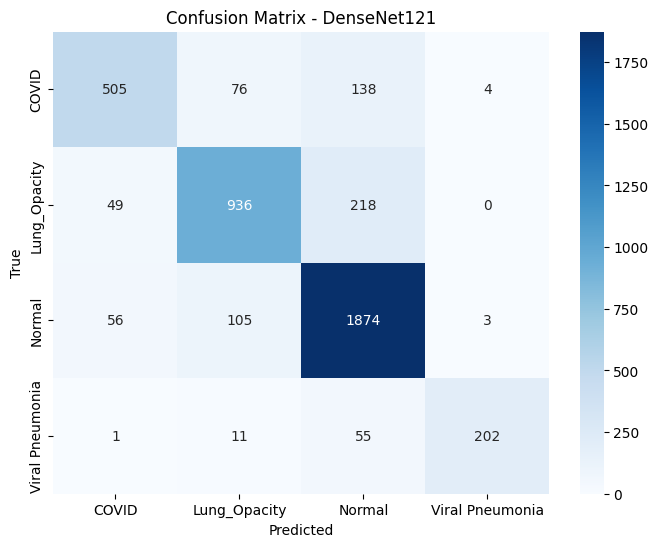

In [17]:
# -------------------------------
# Cell 10: Confusion Matrix heatmap
# -------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - DenseNet121")
plt.show()

True label: Normal
Predicted:  Normal


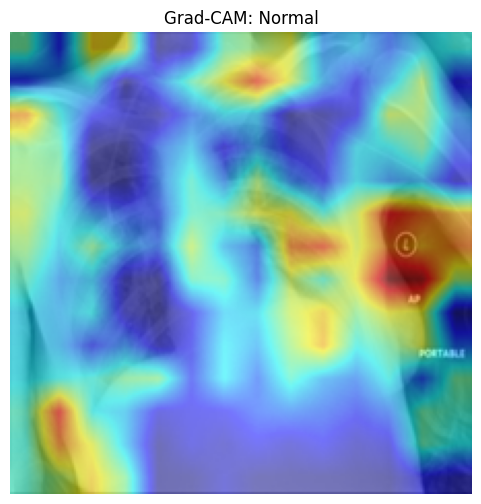

In [22]:
# -------------------------------
# Cell 11: Grad-CAM explanation
# -------------------------------

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import random
import matplotlib.pyplot as plt

# Load the best model
model.load_state_dict(torch.load("best_densenet121.pth", map_location=device))
model.eval()

# Choose the last convolutional block as target layer
# The previous target_layer = model.features[10] (denseblock4) might not work well.
# Let's try the convolutional layer in the Transition3 block, which is model.features[9].conv
target_layer = model.features[9].conv

# Ensure gradients can be computed for the feature extractor for Grad-CAM
for param in model.features.parameters():
    param.requires_grad = True

cam = GradCAM(model=model, target_layers=[target_layer])

# Pick a random validation image
img_path, true_label = val_dataset_raw.samples[val_idx[random.randint(0, len(val_idx)-1)]]
img_pil = Image.open(img_path).convert("RGB")
img_tensor = val_transform(img_pil).unsqueeze(0).to(device)

# Predict
output = model(img_tensor)
pred_class = torch.argmax(output, dim=1).item()
print(f"True label: {CLASS_NAMES[true_label]}")
print(f"Predicted:  {CLASS_NAMES[pred_class]}")

# Prepare image for overlay
img_np = np.array(img_pil.resize((224,224))) / 255.0

# Generate Grad-CAM heatmap
grayscale_cam = cam(input_tensor=img_tensor, targets=None)[0, :]
visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

plt.figure(figsize=(6,6))
plt.imshow(visualization)
plt.title(f"Grad-CAM: {CLASS_NAMES[pred_class]}")
plt.axis("off")
plt.show()

# Re-freeze the feature extractor after Grad-CAM if further training is intended
for param in model.features.parameters():
    param.requires_grad = False

  0%|          | 0/1000 [00:00<?, ?it/s]

True label: Lung_Opacity
Predicted:  Lung_Opacity
Probabilities: {'COVID': np.float32(0.1494752), 'Lung_Opacity': np.float32(0.81164145), 'Normal': np.float32(0.03704047), 'Viral Pneumonia': np.float32(0.0018429338)}


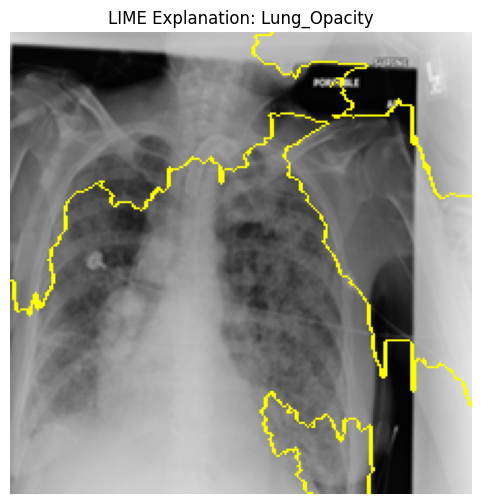

In [23]:
# -------------------------------
# Cell 12: LIME explanation
# -------------------------------

import torch
import numpy as np
from lime import lime_image
from skimage.segmentation import mark_boundaries

def predict_fn(images):
    """
    images: numpy array of shape (n, H, W, 3) in range [0, 255]
    returns: probability array of shape (n, NUM_CLASSES)
    """
    model.eval()
    batch = torch.stack([
        val_transform(Image.fromarray(img.astype(np.uint8)))
        for img in images
    ]).to(device)
    with torch.no_grad():
        outputs = model(batch)
        probs = torch.nn.functional.softmax(outputs, dim=1)
    return probs.cpu().numpy()

# Choose a random validation image (same as above or a new one)
img_path, true_label = val_dataset_raw.samples[val_idx[random.randint(0, len(val_idx)-1)]]
img_pil = Image.open(img_path).convert("RGB").resize((224,224))
img_np = np.array(img_pil)

explainer = lime_image.LimeImageExplainer()
explanation = explainer.explain_instance(
    img_np,
    predict_fn,
    top_labels=NUM_CLASSES,
    hide_color=0,
    num_samples=1000
)

# Get the predicted class index
probs = predict_fn(np.expand_dims(img_np, axis=0))[0]
pred_class = np.argmax(probs)
print(f"True label: {CLASS_NAMES[true_label]}")
print(f"Predicted:  {CLASS_NAMES[pred_class]}")
print(f"Probabilities: {dict(zip(CLASS_NAMES, probs))}")

temp, mask = explanation.get_image_and_mask(
    label=pred_class,
    positive_only=True,
    num_features=10,
    hide_rest=False
)

plt.figure(figsize=(6,6))
plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.title(f"LIME Explanation: {CLASS_NAMES[pred_class]}")
plt.axis("off")
plt.show()